### Things to do


- try for dataloading to check the no. of epochs is sufficiently high. 
- the data_ready/data_lock trigger in the hpc stuff is highly fragile. 
- normalising the inputs like in Madisson 
- look at impact of double/single loss?
- bring diff activations to unet
- remove fallbacks in model.py which input fallback data
- in generate_data write some code to split across CPUs if CPU used, else keep as-is

In [ ]:
%run ../run.py

2026-05-18 20:55:11,973 INFO __main__: Requested device: cpu, using device: CPU
2026-05-18 20:55:15,743 INFO __main__: Fine timestep is 4.5e+02s, giving a total of 0.17 years of rollout. The coarsened timestep is 3.6e+03s.
2026-05-18 20:55:15,745 INFO __main__: No existing data found, generating new dataset at u:\Users\Thomas\Documents\Newcastle\QG\QG\data\data_hr512_nx64_01
2026-05-18 20:55:15,745 INFO model.ML.generate_data: Generating 6 trajectories with 1500 steps.
2026-05-18 20:55:16,936 INFO model.ML.generate_data: Using tuned jet initialisation for data generation (n_jets=6)
2026-05-18 20:55:20,941 INFO model.ML.generate_data: Initialised batch of 6 trajectories
2026-05-18 20:55:22,214 INFO model.ML.generate_data: Generating current batch of 6 trajectories, shape: (6, 1500, 2, 64, 64)


Saved GIF to: U:\Users\Thomas\Documents\Newcastle\QG\QG\outputs\data_diagnostics\traj_00000_first_traj.gif


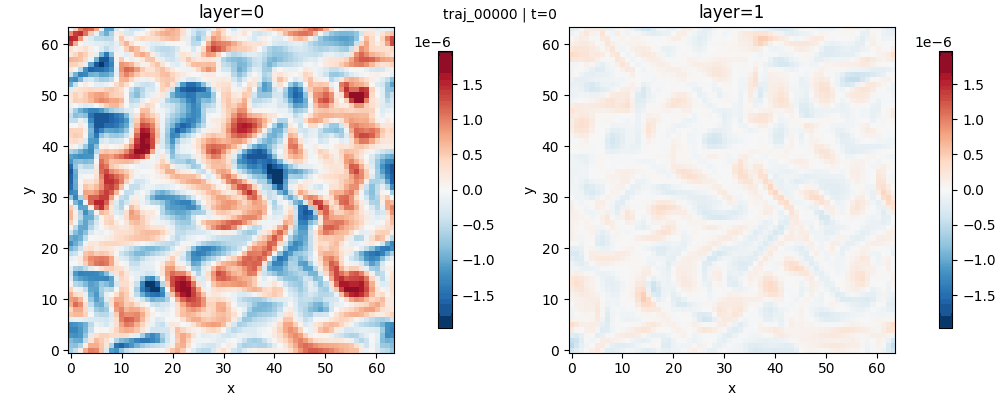

In [ ]:
from matplotlib import animation
from IPython.display import Image, display
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import zarr

def _find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "config" / "default.yaml").exists():
            return p
    raise FileNotFoundError("Could not locate project root containing data/ and config/default.yaml")


repo_root = _find_project_root(Path.cwd())
traj_group_path = repo_root / "data" / "data_hr512_nx64_01" / "trajectories.zarr" / "trajectories"

zg = zarr.open_group(str(traj_group_path), mode="r")
traj_keys = sorted(zg.array_keys())
if not traj_keys:
    raise ValueError(f"No trajectories found in {traj_group_path}")

first_key = traj_keys[0]
traj0 = np.asarray(zg[first_key])  # (time, nz, ny, nx)
print(f"Loaded {first_key} with shape {traj0.shape}, dtype={traj0.dtype}")

nt, nz, ny, nx = traj0.shape
# Build a compact GIF from the first trajectory (every 10 timesteps)
frame_step = 100
frames = np.arange(0, nt, frame_step)

vlim = np.nanpercentile(np.abs(traj0), 99)
if not np.isfinite(vlim) or vlim == 0:
    vlim = 1.0

fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)
if nz == 1:
    axes = [axes]

ims = []
for iz, ax in enumerate(axes):
    im = ax.imshow(traj0[0, iz], cmap="RdBu_r", origin="lower", vmin=-vlim, vmax=vlim, animated=True)
    ax.set_title(f"layer={iz}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, shrink=0.85)
    ims.append(im)

time_txt = fig.text(0.5, 0.98, "t=0", ha="center", va="top")


def _update(frame_idx):
    for iz, im in enumerate(ims):
        im.set_data(traj0[frame_idx, iz])
    time_txt.set_text(f"{first_key} | t={frame_idx}")
    return [*ims, time_txt]

ani = animation.FuncAnimation(
    fig,
    _update,
    frames=frames,
    interval=80,
    blit=False,
)

gif_path = repo_root / "outputs" / "data_diagnostics" / f"{first_key}_first_traj.gif"
gif_path.parent.mkdir(parents=True, exist_ok=True)
ani.save(gif_path, writer=animation.PillowWriter(fps=12))
plt.close(fig)

print(f"Saved GIF to: {gif_path}")
display(Image(filename=str(gif_path)))